In [61]:
# Bibliotecas necessárias
import pandas as pd
import numpy as np
import statistics as st

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import seaborn as sns

import warnings
from sklearn.svm import SVR
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
import scipy.stats as st

import statsmodels.api as sm

from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.stats.stattools import durbin_watson

from statsmodels.stats.stattools import durbin_watson
warnings.filterwarnings("ignore") # not to display warnings

In [62]:
# Load the data
df=pd.read_csv(r'C:\Users\g_tei\Downloads\forestfires.csv') # <---- eu estou a usar a versão online então alterei aq
# Explore the file
df.info()
df.head() # -> primeiras 5 linhas
# df.tail() -> últimas 5 linhas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


O dataset tem 517 linhas e 13 colunas.

As variáveis são X, Y, month, day, FFMC, DMC, DC, ISI, temp, RH, wind, rain e area.

Existem 2 tipos de variáveis:

- Variáveis quantitativas (numéricas): X, Y, FFMC, DMC, DC, ISI, temp, RH, wind, rain e area
- Variáveis qualitativas (categóricas): month, day

Não existem valores em falta.

In [63]:
# Obtenha um resumo das estatísticas descritivas básicas de todas as variáveis numéricas em forestfires.csv.
df.describe() 

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


Variável area:
- Média: 12.85
- Mediana: 0.52
- Desvio padrão: 63.66

Variável temp:
- Mínimo: 2.20
- Máximo: 33.30

Variável humidade (RH):
- Média: 44.3

Na variável area, a média é significativamente maior do que a mediana, o que mostra que há muitos incêndios pequenos e alguns grandes.

In [64]:
# Mês com mais incêndios
from statistics import mode as stat_mode
moda=stat_mode(np.array(df['month']))
print("The mode is", moda)

The mode is aug


In [65]:
absolutas_freq = df['month'].value_counts().sort_index()# Frequências absolutas
# Combinar num único DataFrame do Pandas
pd.DataFrame({'Frequência absoluta': absolutas_freq})

,Frequência absoluta
month,
apr,9
aug,184
dec,9
feb,20
jan,2
jul,32
jun,17
mar,54
may,2


O mês de agosto apresenta a maior frequência absoluta de incêndios, com 184 ocorrências.

In [66]:
# Dias da semana com mais incêndios
moda=stat_mode(np.array(df['day']))
print("The mode is", moda)

The mode is sun


In [67]:
absolutas_freq = df['day'].value_counts().sort_index()# Frequências absolutas
# Combinar num único DataFrame do Pandas
pd.DataFrame({'Frequência absoluta': absolutas_freq})

,Frequência absoluta
day,
fri,85
mon,74
sat,84
sun,95
thu,61
tue,64
wed,54


O dia da semana domingo apresenta a maior frequência absoluta de incêndios, com 95 ocorrências.

Os incêndios concentram-se sobretudo em agosto e setembro, ou seja, no fim do verão.

In [68]:
# Área média ardida por mês
df.groupby('month')['area'].mean()

month
apr     8.891111
aug    12.489076
dec    13.330000
feb     6.275000
jan     0.000000
jul    14.369687
jun     5.841176
mar     4.356667
may    19.240000
nov     0.000000
oct     6.638000
sep    17.942616
Name: area, dtype: float64

Os incêndios foram mais graves em maio, pois a área média ardida nesse mês foi 19.24 ha.

In [69]:
# Temperatura média por mês
df.groupby('month')['temp'].mean()

month
apr    12.044444
aug    21.631522
dec     4.522222
feb     9.635000
jan     5.250000
jul    22.109375
jun    20.494118
mar    13.083333
may    14.650000
nov    11.800000
oct    17.093333
sep    19.612209
Name: temp, dtype: float64

O mês com mais incêndios é agosto, mas o mês com maior área média ardida é maio.

Esta situação pode dever-se ao facto de, em maio, terem ocorrido poucos incêndios, mas com áreas ardidas relativamente elevadas.

In [70]:
# Selecionar incêndios com area > 10 ha
df[df['area']>10]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
194,2,2,aug,tue,94.8,108.3,647.1,17.0,24.6,22,4.5,0.0,10.01
195,2,5,aug,fri,93.9,135.7,586.7,15.1,23.5,36,5.4,0.0,10.02
196,6,5,apr,thu,81.5,9.1,55.2,2.7,5.8,54,5.8,0.0,10.93
197,4,5,sep,thu,92.9,137.0,706.4,9.2,21.5,15,0.9,0.0,11.06
198,3,4,sep,tue,91.0,129.5,692.6,7.0,13.9,59,6.3,0.0,11.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,6,5,aug,tue,96.1,181.1,671.2,14.3,33.3,26,2.7,0.0,40.54
499,7,5,aug,tue,96.1,181.1,671.2,14.3,27.3,63,4.9,6.4,10.82
504,4,3,aug,wed,94.5,139.4,689.1,20.0,28.9,29,4.9,0.0,49.59
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29


In [71]:
# Nº de incêndios com area > 10 ha
df[df['area']>10].shape

(95, 13)

O número de incêndios com área superior a 10 é 95.

In [72]:
# Temperatura Média quando area > 10 ha
round(df[df['area']>10]['temp'].mean(), 2)

np.float64(19.06)

A temperatura média nos incêndios com área superior a 10 é 19.06°C.

In [73]:
# Incêndios com temperatura > 30°C
df[df['temp']>30]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
28,6,3,sep,sat,93.4,145.4,721.4,8.1,30.2,24,2.7,0.0,0.00
421,2,4,aug,wed,95.2,217.7,690.0,18.0,30.8,19,4.5,0.0,0.00
480,9,9,jul,thu,93.2,114.4,560.0,9.5,30.2,25,4.5,0.0,2.75
481,4,3,jul,thu,93.2,114.4,560.0,9.5,30.2,22,4.9,0.0,0.00
483,8,6,aug,sun,94.9,130.3,587.1,14.1,31.0,27,5.4,0.0,0.00
484,2,5,aug,sun,94.9,130.3,587.1,14.1,33.1,25,4.0,0.0,26.43
485,2,4,aug,mon,95.0,135.5,596.3,21.3,30.6,28,3.6,0.0,2.07
491,4,4,aug,thu,95.8,152.0,624.1,13.8,32.4,21,4.5,0.0,0.00
492,1,3,aug,fri,95.9,158.0,633.6,11.3,32.4,27,2.2,0.0,0.00
494,6,6,aug,sat,96.0,164.0,643.0,14.0,30.8,30,4.9,0.0,8.59


In [74]:
# Nº de incêndios com temperatura > 30°C
df[df['temp']>30].shape

(13, 13)

O número de incêndios com temperatura superior a 30°C é 13.

Há poucos incêndios com área muito grande, mas eles existem e também existem alguns casos com temperaturas muito elevadas.

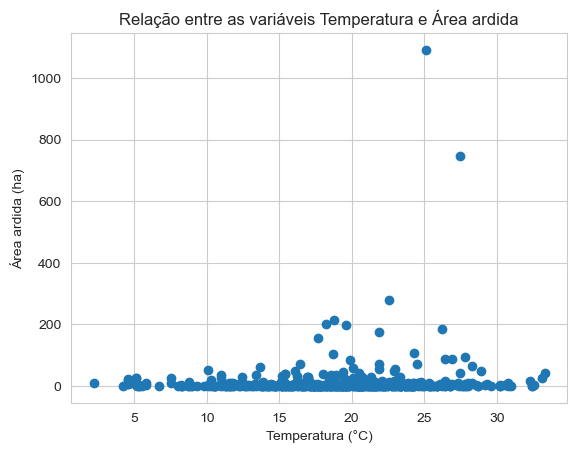

In [75]:
# Gráfico de dispersão para avaliar a relação entre temperatura e área ardida
fig, axes = plt.subplots(nrows=1, ncols=1)

axes.scatter(df['temp'], df['area'])
axes.set_title('Relação entre as variáveis Temperatura e Área ardida')
axes.set_xlabel('Temperatura (°C)')
axes.set_ylabel('Área ardida (ha)')

plt.show()

O gráfico de dispersão mostra grande dispersão dos pontos e ausência de relação linear clara entre a temperatura e a área ardida. A maioria dos valores de área é próxima de 0, com alguns outliers elevados.

In [76]:
# Cálculo do coeficiente de correlação de Pearson entre temperatura e área ardida
pearson_corr, _ = pearsonr(df['temp'], df['area'])
print("O coeficiente de correlação de Pearson entre temperatura e área ardida é", "{:.3f}".format(pearson_corr))

O coeficiente de correlação de Pearson entre temperatura e área ardida é 0.098


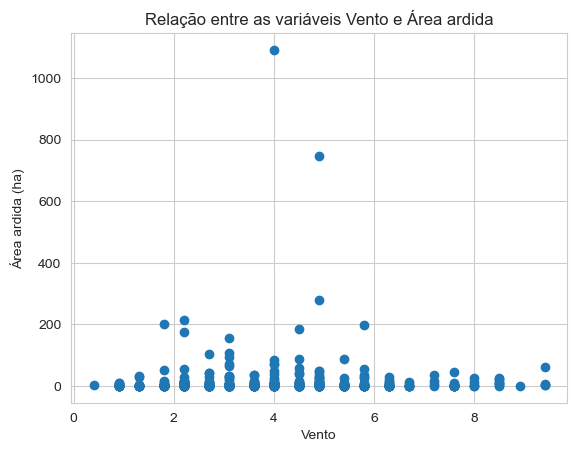

In [77]:
# Gráfico de dispersão para avaliar a relação entre vento e área ardida
fig, axes = plt.subplots(nrows=1, ncols=1)

axes.scatter(df['wind'], df['area'])
axes.set_title('Relação entre as variáveis Vento e Área ardida')
axes.set_xlabel('Vento')
axes.set_ylabel('Área ardida (ha)')

plt.show()

O gráfico de dispersão mostra grande dispersão dos pontos e ausência de relação linear clara entre o vento e a área ardida. A maioria dos valores de área é próxima de 0, com alguns outliers elevados.

In [78]:
# Cálculo do coeficiente de correlação de Pearson entre vento e área ardida
pearson_corr, _ = pearsonr(df['wind'], df['area'])
print("O coeficiente de correlação de Pearson entre vento e área ardida é", "{:.3f}".format(pearson_corr))

O coeficiente de correlação de Pearson entre vento e área ardida é 0.012


Text(0.5, 1.0, 'Mapa de correlação')

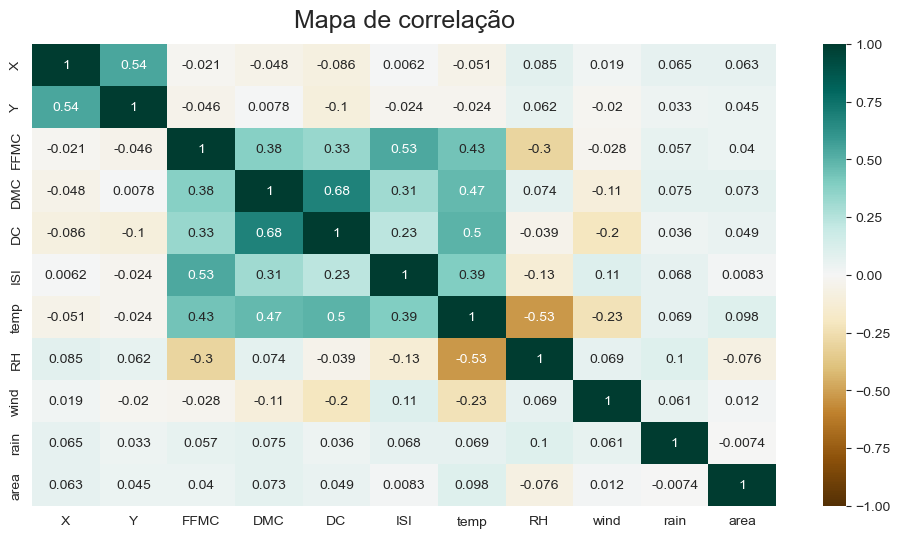

In [79]:
# Apresentação de uma matriz de correlação para todas as variáveis numéricas em *forestfires*.
df_num=df.drop(['month','day'],axis=1) # eliminar as variáveis qualitativas
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(df_num.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Mapa de correlação', fontdict={'fontsize':18}, pad=12)

O mapa de correlação mostra que as correlações entre as variáveis são, em geral, fracas. 

Em particular, a variável area apresenta correlações muito baixas com as restantes variáveis, pelo que existe ausência de relação linear forte.

Nenhuma variável isolada explica bem a área ardida. A variável area parece depender de vários fatores ao mesmo tempo, e não apenas de temperatura ou vento.

Text(0.5, 1.0, 'Distribuição da área ardida')

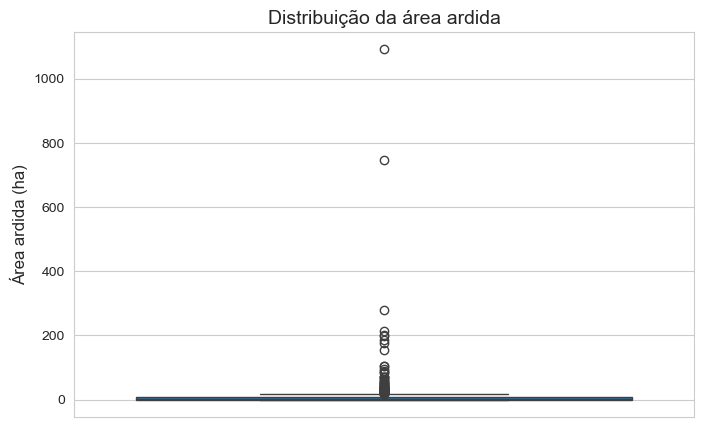

In [80]:
# Boxplot da area
sns.set_style('whitegrid') # selecionar o tema, facultativo
plt.figure(figsize=(8,5)) # fixar a dimensão da figura, facultativo

sns.boxplot(df['area'])
plt.ylabel("Área ardida (ha)", size=12)
plt.title("Distribuição da área ardida", size=14)

O boxplot da área ardida mostra uma mediana próxima de 0, baixa variabilidade na maioria dos dados e uma distribuição assimétrica à direita, com vários outliers elevados.

In [81]:
# Amplitude inter-quartil da área ardida
q_25 = np.quantile(df['area'], 0.25) 
q_75 = np.quantile(df['area'], 0.75) 

IQR=q_75-q_25
print("A amplitude inter-quartil da área ardida (em ha) é", IQR)

A amplitude inter-quartil da área ardida (em ha) é 6.57


In [82]:
# Existência de outliers
bi=np.quantile(df['area'], 0.25)-1.5*(np.quantile(df['area'], 0.75)-np.quantile(df['area'], 0.25)) # BI=Q1-1,5×IQR (para outliers inferiores)
print(bi)

bs=np.quantile(df['area'], 0.75)+1.5*(np.quantile(df['area'], 0.75)-np.quantile(df['area'], 0.25)) # BS=Q3+1,5×IQR (para outliers superiores)
print(bs)

outliers = df[(df['area'] < bi) | (df['area'] > bs)]
outliers.shape

-9.855
16.425


(63, 13)

Os limites definidos pelo critério do IQR são -9.855 (inferior) e 16.425 (superior). 

Foram identificados 63 outliers, correspondentes a valores de área ardida superiores ao limite esperado.

Estes resultados confirmam a presença de valores extremos elevados e uma distribuição assimétrica à direita.

In [83]:
# Coeficiente assimetria da área ardida
from scipy.stats import skew
assimetria=skew(df['area'],axis=0,bias=True) # Eixo ao longo do qual o valor da assimetria deve ser medido (por defeito, 0).
print("O coeficiente de assimetria da área ardida é", "{:.3f}".format(assimetria))

O coeficiente de assimetria da área ardida é 12.810


A variável area apresenta assimetria positiva (12.810 > 0), o que revela uma distribuição enviesada à direita, com presença de valores extremos elevados.

In [84]:
# Verificar valores em falta
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Não foram identificados valores em falta no conjunto de dados.

In [85]:
# Verificar duplicados
df.duplicated().sum()

np.int64(4)

Foram identificadas 4 observações duplicadas, no entanto, estas podem corresponder a incêndios distintos com características semelhantes, pelo que não foram removidas.

Considero que outliers são uma parte importante dos dados fornecidos, já que dentro do context de incêndios florestais, estas outliers não são necessáriamente anomalias já que podem ser informação vital ao invés de erros. No entanto, a presença de outliers extremas torna os dados muito assimétricos à direita, logo vou aplicar uma transformação logarítmica de modo a tentar suavizar o impacto deste outliers.

In [86]:
df['area_log'] = np.log1p(df['area'])
df.head(n=10)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_log
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0,0.0


Text(0.5, 1.0, 'Tranformação log(x+1) da área ardida')

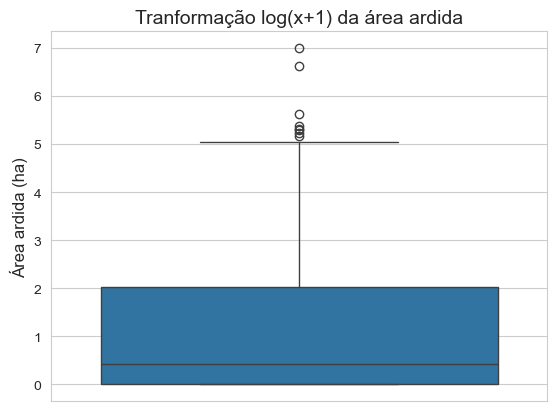

In [87]:
sns.boxplot(df['area_log'])
plt.ylabel("Área ardida (ha)", size=12)
plt.title("Tranformação log(x+1) da área ardida", size=14)

<Axes: >

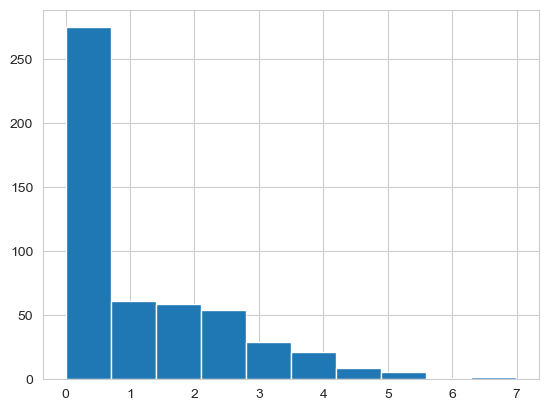

In [88]:
df['area_log'].hist()

Após a tranformação logarítmica da variável Área, vou então analizar de novo o mapa de correlação para ver se houve alguma mudança significativa

Text(0.5, 1.0, 'Mapa de correlação')

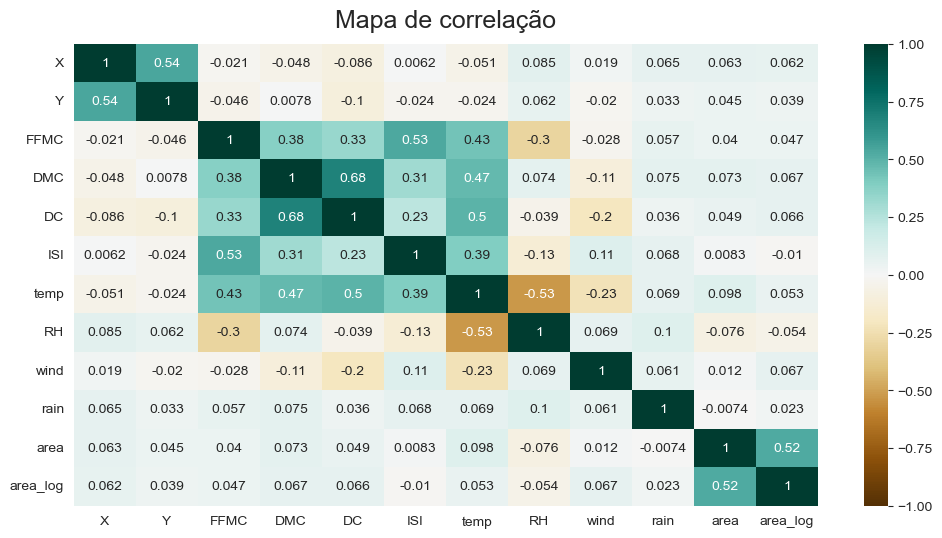

In [89]:
# Apresentação de uma matriz de correlação para todas as variáveis numéricas em *forestfires*.
df_num=df.drop(['month','day'],axis=1) # eliminar as variáveis qualitativas
plt.figure(figsize=(12, 6))
heatmap = sns.heatmap(df_num.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Mapa de correlação', fontdict={'fontsize':18}, pad=12)

In [90]:
X = df[['temp', 'RH', 'wind', 'rain']]
y_original = df['area']

In [91]:
#Transformação do o objetivo
#Nota que eu segui bastante os metodos utilizados no estudo original destes dados, e cheguei à mesma conclusão que eles.
#Acho que não é tecnicament errado ¯\_(ツ)_/¯
y_log = np.log1p(y_original)

#Após ver o estudo em que usaram estes dados, vi que tive de fazer uma normalização dos mesmos
#já que modelos baseados em distâncias como SVM necessitam de dados escalados.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#validação cruzada
rkf = RepeatedKFold(n_splits=10, n_repeats=30, random_state=42)

#modelo SVM
model = SVR(kernel='rbf')

mse_scores = []
mae_scores = []


#Teste dos dados
for train_index, test_index in rkf.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train_log = y_log.iloc[train_index]
    y_test_original = y_original.iloc[test_index].values
    
    # Treinar o modelo
    model.fit(X_train, y_train_log)
    
    # Prever e inverter a transformação logarítmica
    y_pred_log = model.predict(X_test)
    Predict_test = np.expm1(y_pred_log)
    
    
    #erro quadrático médio
    MSE = np.mean((y_test_original - Predict_test)**2)
    
    #erro absoluto médio
    MAE = np.mean(np.abs(y_test_original - Predict_test))
    
    mse_scores.append(MSE)
    mae_scores.append(MAE)

print("--- Resultados (Média de 300 iterações CV) ---")
print("Mean square error =", np.mean(mse_scores))
print("Mean absolute error =", np.mean(mae_scores))

--- Resultados (Média de 300 iterações CV) ---
Mean square error = 4179.193921755601
Mean absolute error = 12.723569153678447


In [92]:
#isto foi um fix sugerido por IA já que tive que usar modelo SVR em vez de OLS
#não é mt crítico, é só uma forma diferente de apresentar a tabela
# import statsmodels.api as sm

# Adicionar a constante (bias) aos dados, algo que o statsmodels exige
X_sm = sm.add_constant(X_scaled)

# Treinar o modelo linear clássico (OLS - Ordinary Least Squares)
modelo_estatistico = sm.OLS(y_log, X_sm).fit()

# E aqui sim, a magia acontece!
print(modelo_estatistico.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.345
Date:                Fri, 08 May 2026   Prob (F-statistic):              0.252
Time:                        19:05:01   Log-Likelihood:                -903.77
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     512   BIC:                             1839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1110      0.061     18.089      0.0

count    466.000000
mean       0.535525
std        1.366878
min       -2.094337
25%       -0.387414
50%       -0.051310
75%        1.294256
max        6.306700
Name: area, dtype: float64
    Real   Predict  Residuals
0    0.0  1.594585  -1.594585
1    0.0  0.260142  -0.260142
2    0.0  0.099452  -0.099452
3    0.0  0.100346  -0.100346
4    0.0  0.045066  -0.045066
6    0.0  0.432256  -0.432256
7    0.0 -0.099960   0.099960
8    0.0  0.915399  -0.915399
9    0.0  0.873182  -0.873182
10   0.0  0.302211  -0.302211


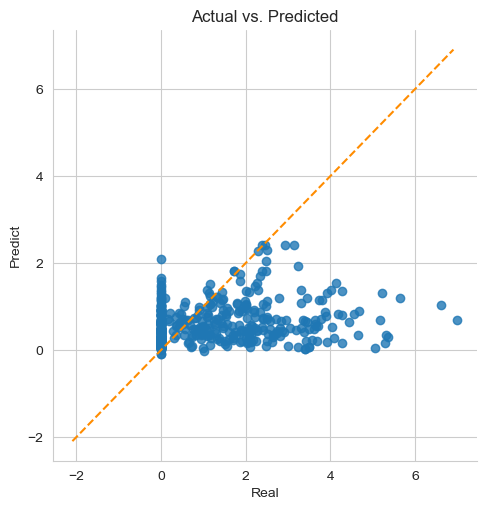

In [93]:
# 1. Linearity
# Plot the scatter diagram between the actual and predicted values. The points should display linear behavior.

Predict= model.predict(X_train)
Residuals = y_train_log - Predict #error
print(Residuals.describe())

data = {'Real': y_train_log,
        'Predict': Predict,
        'Residuals':Residuals}
 
# Dataframe
df_results = pd.DataFrame(data)
print(df_results.head(n=10))

# Scatter diagram
sns.lmplot(x='Real', y='Predict', data=df_results, fit_reg=False)
        
# Plot the line
line_coords = np.arange(df_results.min().min(), df_results.max().max())
plt.plot(line_coords, line_coords, 
             color='darkorange', linestyle='--')
plt.title('Actual vs. Predicted')
plt.show()

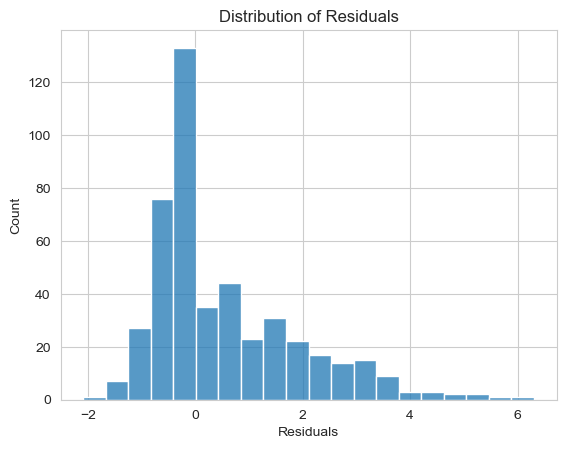

In [94]:
# 2 – Normality of the errors
plt.title('Distribution of Residuals')
sns.histplot(df_results['Residuals'])
plt.show()

In [95]:
# 3 – Multicollinearity
#from patsy import dmatrices
#from statsmodels.stats.outliers_influence import variance_inflation_factor 

# Obtain the design matrix for the linear regression model using ‘Sales’ as the response variable
y, X = dmatrices('area ~ temp+RH+wind+rain', data=df, return_type='dataframe')

# VIF
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['variable'] = X.columns
print(vif)

         VIF   variable
0  52.055240  Intercept
1   1.497878       temp
2   1.430149         RH
3   1.067008       wind
4   1.040048       rain


In [96]:
# 4. Absence of autocorrelation of the errors 
#from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(df_results['Residuals'])

print(f"Estatística de Durbin-Watson: {dw_stat:.4f}")
# As a general rule, test statistic values between 1.5 and 2.5 are considered normal. However, values outside this range 
# may indicate the presence of autocorrelation.
# H0 (null hypothesis): There is no correlation among the residuals.
# H1 (alternative hypothesis): The residuals are autocorrelated.

Estatística de Durbin-Watson: 0.7845


A análise dos resíduos revelou uma forte autocorrelação positiva (Durbin-Watson = 0.78). Este comportamento era esperado, uma vez que o modelo foi treinado apenas com 4 variáveis meteorológicas diretas, ignorando a componente espacial (X, Y), a sazonalidade (mês) e a acumulação temporal de seca (índices FFMC, DMC, DC). Isto indica que os seus erros sofrem influência das dependências espácio-temporais não modeladas.

Após ter pesquisado um pouco, cheguei à conclusão que não é correto aplicar testes de significância a este modelo de modo a provar se este é (ou não) útil. Então, vou seguir o que me foi sugerido na minha pesquisa e no estudo dos autores originais em que analizaram o dataframe, e comparar com um modelo ingênuo (naive mean predictor)

Para criar este modelo ingênuo, estabeleci estabeleci estes parâmetros:

    Durante o treino, o modelo ignora completamente a meteorologia (não olha para a Temperatura, Vento, etc.).

    Ele simplesmente calcula a média aritmética da área ardida de todos os incêndios nesse conjunto de treino (ex: "A média dá 12.8 hectares").

    Quando vai prever os dados de teste, ele diz: "Não sei como está o tempo, por isso vou prever 12.8 hectares para todos os casos".

Por isso a lógica de decisão vai ser algo do gênero:

    Se o SVR tiver um MAE inferior ao MAE deste modelo ingénuo, significa que as variáveis meteorológicas e a transformação não-linear do kernel RBF ajudaram o modelo a aprender padrões reais e a afinar a previsão. O modelo é útil!

    Se o MAE do SVR for igual ou superior, significa que a meteorologia introduziu apenas "ruído" e o modelo perdeu para a simples média estatística.

A treinar os modelos e a calcular erros... (Isto pode demorar alguns segundos)

--- RESULTADOS GLOBAIS DE PREVISÃO ---
MAE do Modelo SVR: 12.7236 hectares
MAE do Modelo Ingénuo: 18.6097 hectares
Conclusão: O teu SVR superou a Baseline. O modelo é preditivamente útil!


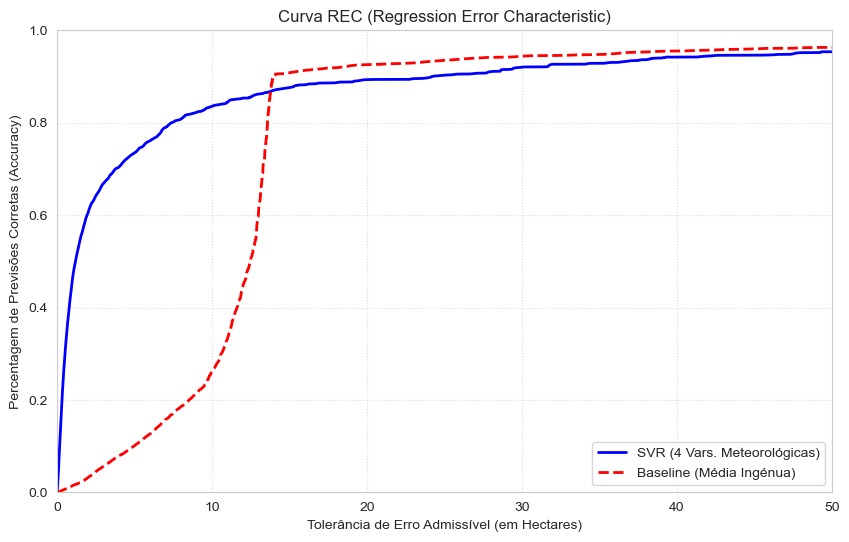

In [97]:
#basicamente estou tipo a copiar o que fizeram no estudo original destes dados
X = df[['temp', 'RH', 'wind', 'rain']]
y_original = df['area']
y_log = np.log1p(y_original)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rkf = RepeatedKFold(n_splits=10, n_repeats=30, random_state=42)
model = SVR(kernel='rbf')

#listas para armazenar os resultados-
mae_svr_list = []
mae_naive_list = []

#guardar todos os erros absolutos para construir a curva REC
all_errors_svr = []
all_errors_naive = []

# validação cruzada
print("A treinar os modelos e a calcular erros... (Isto pode demorar alguns segundos)")
for train_index, test_index in rkf.split(X_scaled):
    # Divisão treino/teste
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train_log = y_log.iloc[train_index]
    y_test_original = y_original.iloc[test_index].values
    
    # --- MODELO A: SVR  ---
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred_svr = np.expm1(y_pred_log) # Inverter transformação
    
    # --- MODELO B: NAIVE PREDICTOR ---
    # Calcular a média real da área no treino
    mean_area_train = y_original.iloc[train_index].mean()
    # Prever sempre esse valor exato para o teste
    y_pred_naive = np.full_like(y_test_original, fill_value=mean_area_train, dtype=float)
    
    # --- CÁLCULO DOS ERROS (MAE) NESTA ITERAÇÃO ---
    mae_svr = np.mean(np.abs(y_test_original - y_pred_svr))
    mae_naive = np.mean(np.abs(y_test_original - y_pred_naive))
    
    mae_svr_list.append(mae_svr)
    mae_naive_list.append(mae_naive)
    
    # Guardar os erros individuais para o gráfico (Curva REC)
    all_errors_svr.extend(np.abs(y_test_original - y_pred_svr))
    all_errors_naive.extend(np.abs(y_test_original - y_pred_naive))

#comparação de mae
print("\n--- RESULTADOS GLOBAIS DE PREVISÃO ---")
print(f"MAE do Modelo SVR: {np.mean(mae_svr_list):.4f} hectares")
print(f"MAE do Modelo Ingénuo: {np.mean(mae_naive_list):.4f} hectares")

if np.mean(mae_svr_list) < np.mean(mae_naive_list):
    print("Conclusão: O teu SVR superou a Baseline. O modelo é preditivamente útil!")
else:
    print("Conclusão: O teu SVR não conseguiu bater a média. (Isto seria preocupante)")

# curva rec
def calculate_rec(errors):
    # O Eixo X é o erro ordenado do menor para o maior
    sorted_errors = np.sort(errors)
    # O Eixo Y é a percentagem acumulada (quantos % dos casos falham menos do que X)
    accuracy = np.arange(1, len(sorted_errors) + 1) / float(len(sorted_errors))
    return sorted_errors, accuracy

# Calcular os pontos para os dois modelos
tol_svr, acc_svr = calculate_rec(all_errors_svr)
tol_naive, acc_naive = calculate_rec(all_errors_naive)

# Plot do gráfico
plt.figure(figsize=(10, 6))

# Linha do teu modelo SVR (Azul sólido)
plt.plot(tol_svr, acc_svr, label='SVR (4 Vars. Meteorológicas)', color='blue', linewidth=2)

# Linha do Modelo Ingénuo (Vermelho tracejado)
plt.plot(tol_naive, acc_naive, label='Baseline (Média Ingénua)', color='red', linestyle='--', linewidth=2)

# Configurações visuais (Limitamos o X a 50 hectares para focar onde estão 90% dos incêndios)
plt.xlim(0, 50) 
plt.ylim(0, 1.0)
plt.title('Curva REC (Regression Error Characteristic)')
plt.xlabel('Tolerância de Erro Admissível (em Hectares)')
plt.ylabel('Percentagem de Previsões Corretas (Accuracy)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')

plt.show()

Logo, chegamos à conclusão de que o modelo é útil na previsão da área incendiada por hectares.